In [17]:
!pip install tensorflow

In [18]:
import numpy as np
import tensorflow as tf
import pandas as pd
import seaborn as sns  # to plot images and statical version of data
import matplotlib.pyplot as plt

In [19]:
house_sale = pd.read_csv('kc_house_data.csv')

In [20]:
house_sale

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [21]:
house_sale.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


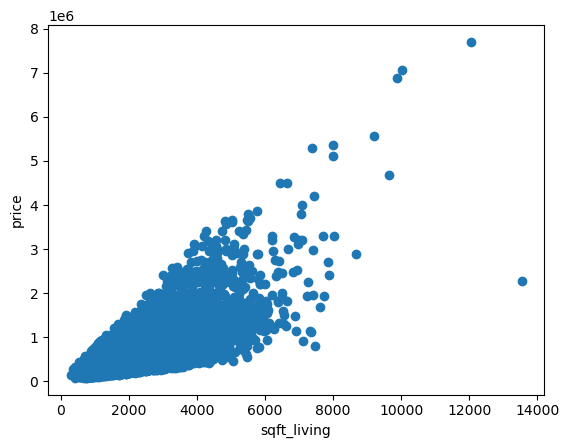

In [22]:
plt.scatter(house_sale['sqft_living'], house_sale['price'])
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.show()

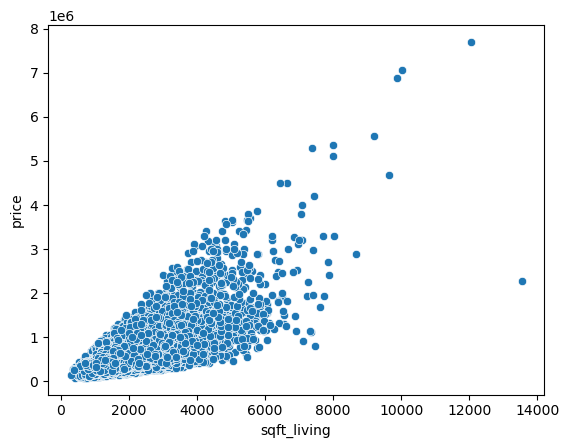

In [23]:
sns.scatterplot(x= 'sqft_living', y= 'price', data=house_sale)
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.show()

<Axes: >

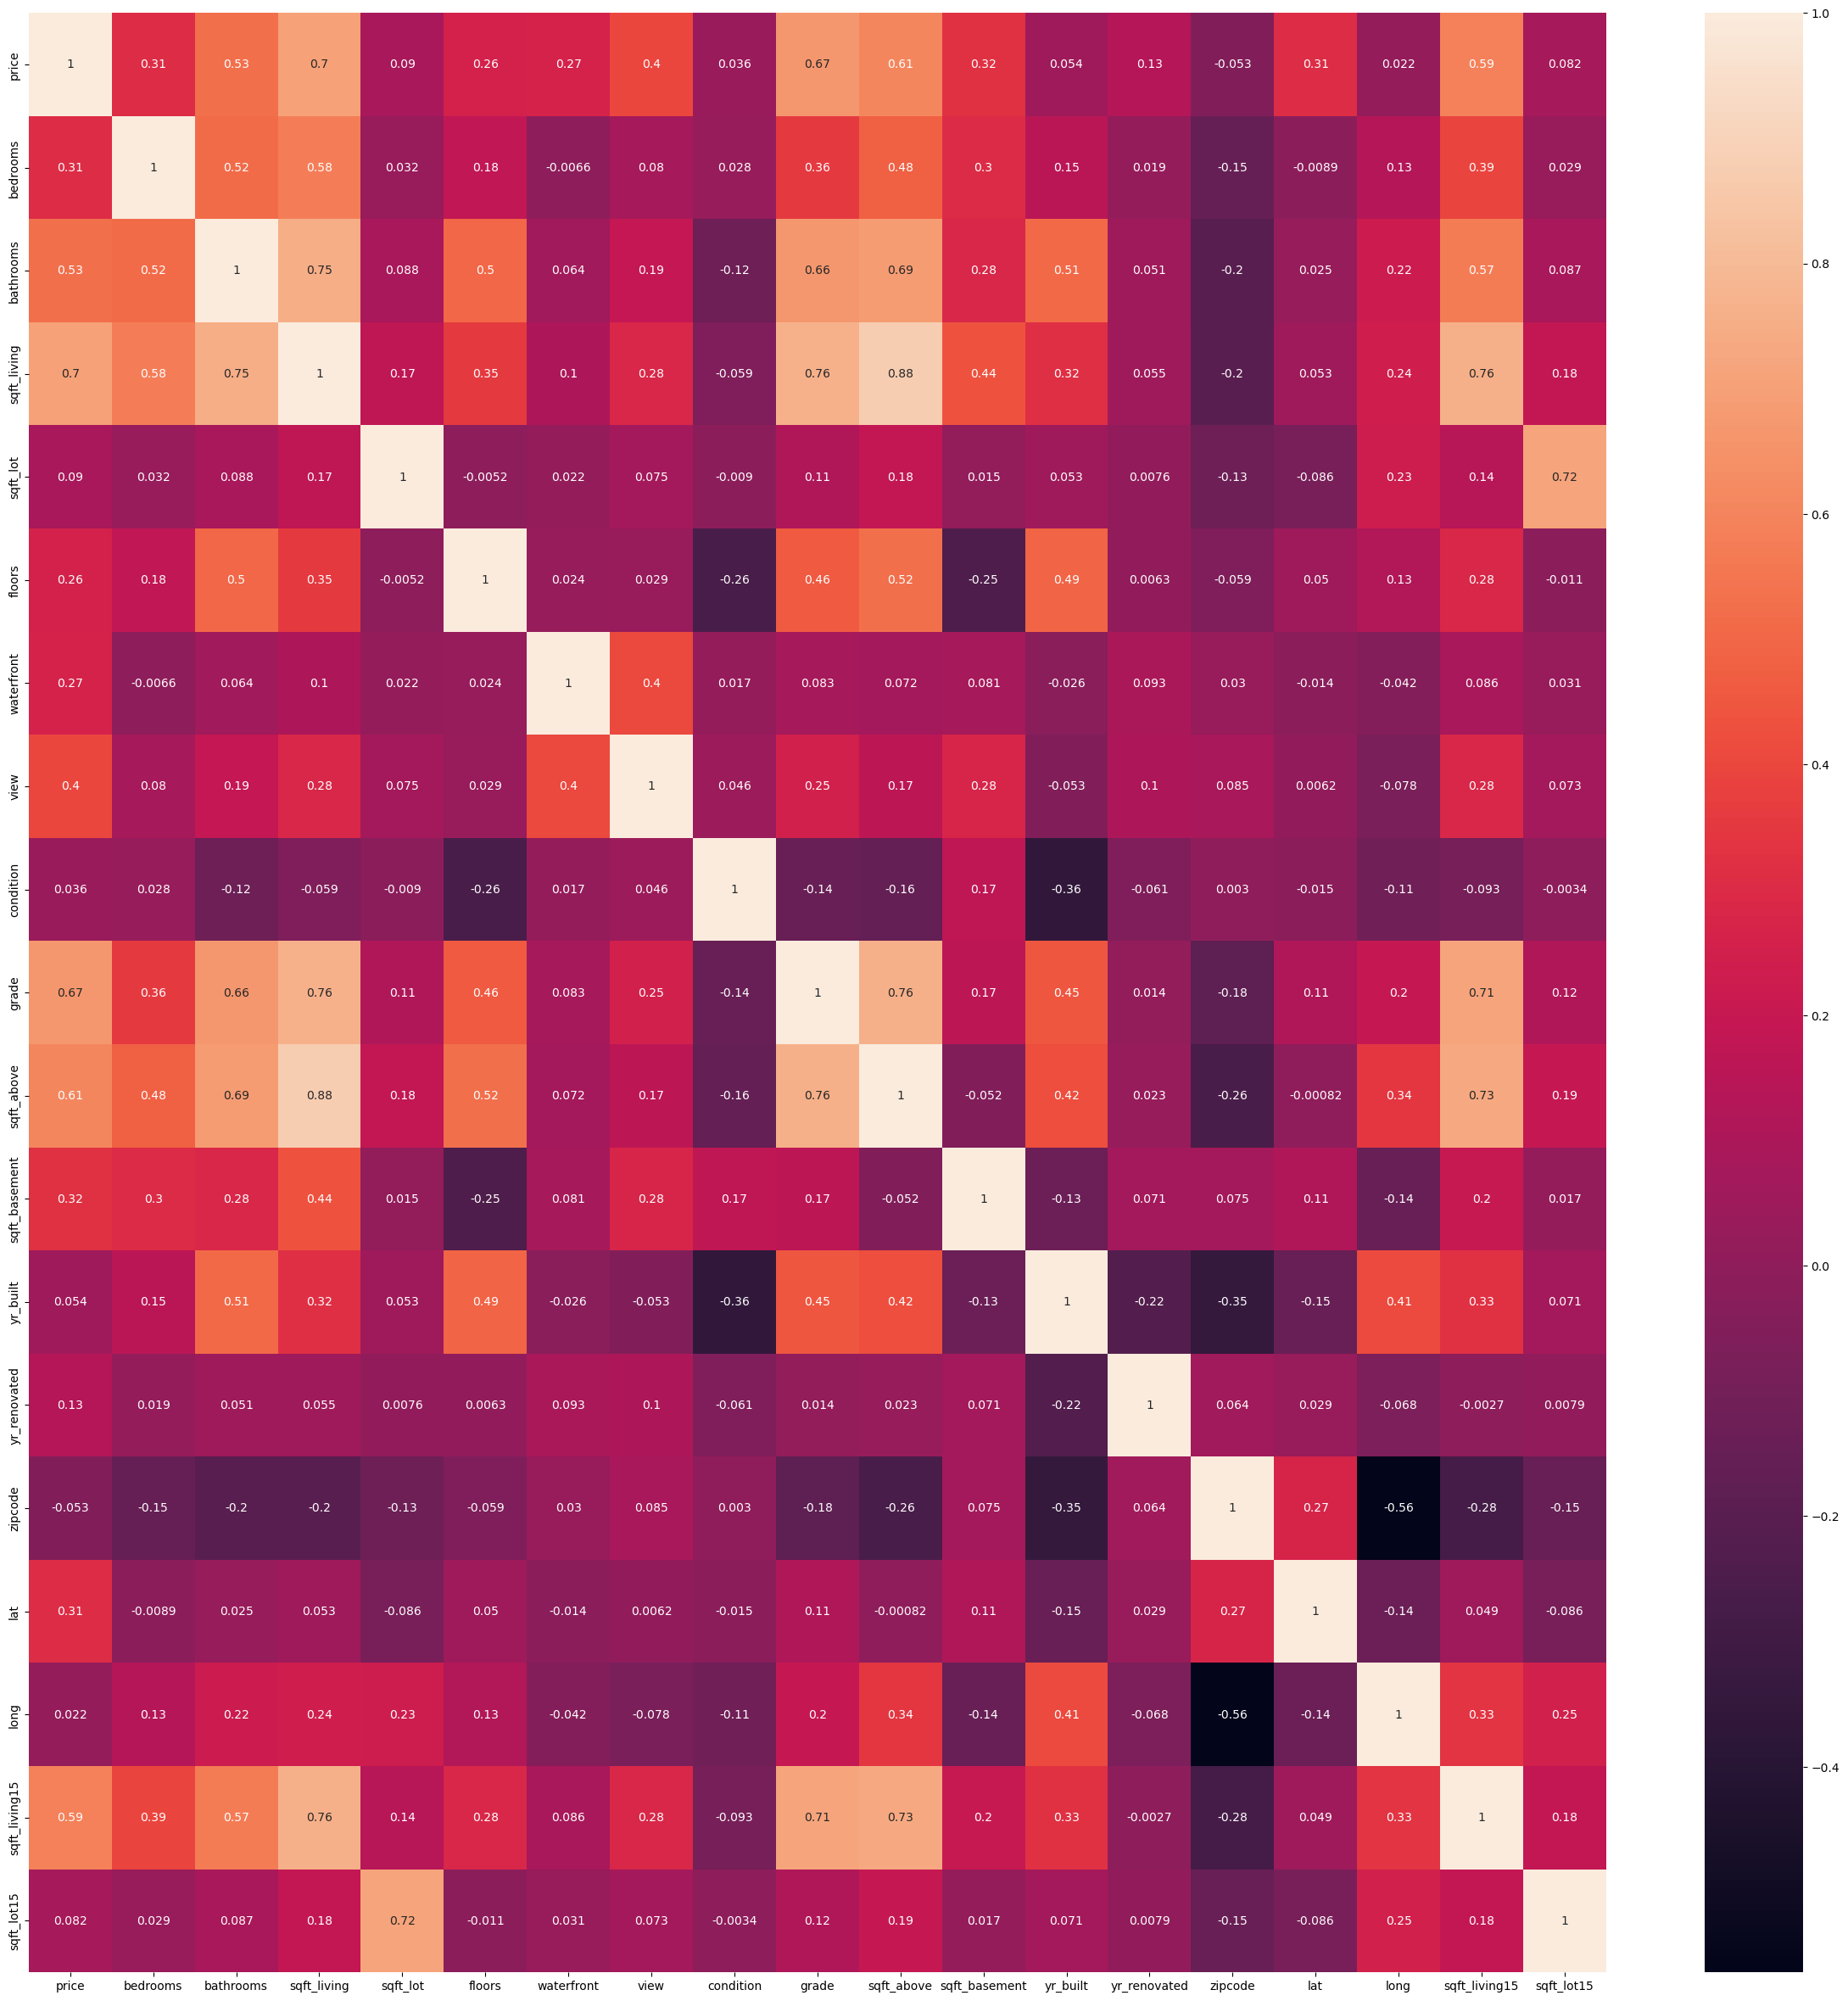

In [24]:
house_sale=house_sale.drop(['id','date'],axis=1)
f, ax = plt.subplots(figsize = (30, 30))
sns.heatmap(house_sale.corr(), annot= True)


 # step:3 Traning and testing data split

In [25]:
X = house_sale[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement']]
y = house_sale['price']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print(y)
y = y.values.reshape(-1,1)
print(y)
y_scaled = scaler.fit_transform(y)


0        221900.0
1        538000.0
2        180000.0
3        604000.0
4        510000.0
           ...   
21608    360000.0
21609    400000.0
21610    402101.0
21611    400000.0
21612    325000.0
Name: price, Length: 21613, dtype: float64
[[221900.]
 [538000.]
 [180000.]
 ...
 [402101.]
 [400000.]
 [325000.]]


# step:4 Model traning

In [26]:
# spilitting data into training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, train_size = 0.75)

# in tensorflow 2.0, keras API come automatically with tensorflow 2.0
ANN_model = tf.keras.models.Sequential()
ANN_model.add(tf.keras.layers.Dense(units = 100, activation = 'relu', input_shape = (7,))) #we use Dense when we have fully connected atificial neural network
# now we are adding one more layer to the network
ANN_model.add(tf.keras.layers.Dense(units = 100, activation = 'relu'))
ANN_model.add(tf.keras.layers.Dense(units = 100, activation = 'relu'))
# now adding the output layer
ANN_model.add(tf.keras.layers.Dense(units = 1, activation = 'linear'))

ANN_model.summary()

ANN_model.compile(optimizer = 'Adam', loss= 'mean_squared_error')
# Splitting training dataset with validation, so that model can preditc validation dataset simultaneously as well
hist = ANN_model.fit(X_train, y_train, epochs = 100, batch_size=50, validation_split = 0.2)


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,101 (82.43 KB)

 Trainable params: 21,101 (82.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 2/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 3/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 4/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 5/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 6/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 7/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 8/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 9/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 10/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.9560e-04 - val_loss: 0.0010
Epoch 11/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.9287e-04 - val_loss: 0.0011
Epoch 12/100
260/260 ━━━━━━━━━━━━

# Evalution of model

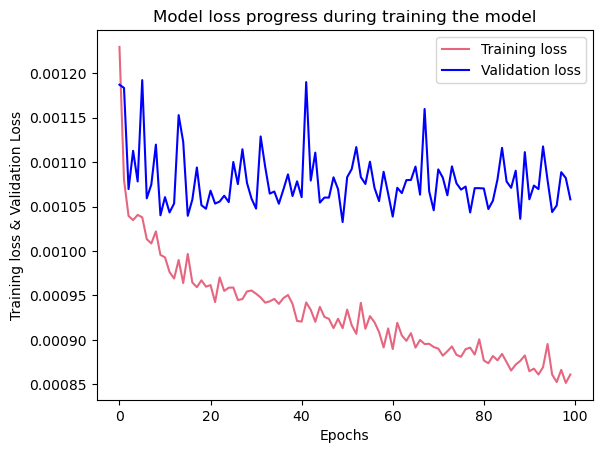

In [33]:
hist.history.keys()
plt.plot(hist.history['loss'], color=[.9,.4,.5], label='Training loss')
plt.plot(hist.history['val_loss'], color='b', label='Validation loss')
plt.title('Model loss progress during training the model')
plt.xlabel('Epochs')
plt.ylabel('Training loss & Validation Loss')
plt.legend()
plt.show()

In [34]:
#  'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement'
X_test_1 = np.array([[4, 3, 1960, 5000, 1, 2000, 3000]])

scaler_1 = MinMaxScaler()
X_test_scaled_1 = scaler_1.fit_transform(X_test_1)

y_predict_1 = ANN_model.predict(X_test_scaled_1) #predicting the values

y_predict_1 = scaler.inverse_transform(y_predict_1)
y_predict_1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[240846.62]], dtype=float32)

In [ ]:
y_predict = ANN_model.predict(X_test) #predicting the values
plt.plot(y_test, y_predict, '*', color = 'r')
plt.xlabel('Model Prediction')
plt.ylabel('True Values')
plt.show()

In [ ]:
# Now visualising the Model performance with different error type
k = X_test.shape[1]
n = len(X_test)
y_predict_orig = scaler.inverse_transform(y_predict)
y_test_orig = scaler.inverse_transform(y_test)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

RMSE = float(format(np.sqrt(mean_squared_error(y_test_orig, y_predict_orig)), '0.3f'))
MSE = mean_squared_error(y_test_orig, y_predict_orig)
MAE = mean_absolute_error(y_test_orig, y_predict_orig)
r2 = r2_score(y_test_orig, y_predict_orig)
print('RMSE =', RMSE, '\nMSE=', MSE, '\nMAE=', MAE, '\nR2=', r2)


In [38]:
ANN_model.save("house_price_model.keras")
print("Model Saved Successfully!")

Model Saved Successfully!
